# Unit 2 | NLP 05 — Model Showdown: Classical vs. Semantic

This notebook runs a controlled comparison of every vectorization approach covered in the series:

| Representation | Classifiers |
|---|---|
| CountVectorizer | Multinomial Naive Bayes, Logistic Regression |
| TF-IDF | Logistic Regression, Random Forest |
| Sentence Embeddings | Logistic Regression, Random Forest |

Same dataset. Same train/test split. Same random seed. May the best model win.

**Dataset:** sklearn 20 Newsgroups

In [1]:
import warnings; warnings.filterwarnings('ignore')
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import fetch_20newsgroups
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline
from sklearn.metrics import (accuracy_score, f1_score,
                             classification_report, confusion_matrix)
from sentence_transformers import SentenceTransformer

pd.set_option('display.max_columns', 100)
pd.set_option('display.max_rows', 100)
plt.style.use('dark_background')

In [2]:
# ── CONFIGURATION ────────────────────────────────────────────────────────────
CATEGORIES   = ['sci.space', 'comp.graphics', 'rec.sport.hockey', 'talk.religion.misc']
RANDOM_STATE = 42
MAX_FEATURES = 10000
EMB_MODEL    = 'all-MiniLM-L6-v2'
# ─────────────────────────────────────────────────────────────────────────────

In [3]:
train = fetch_20newsgroups(
    subset='train', categories=CATEGORIES,
    remove=('headers', 'footers', 'quotes'), random_state=RANDOM_STATE
)
test = fetch_20newsgroups(
    subset='test', categories=CATEGORIES,
    remove=('headers', 'footers', 'quotes'), random_state=RANDOM_STATE
)

print(f"Train: {len(train.data):,} docs   Test: {len(test.data):,} docs")
print(f"Classes: {train.target_names}")

Train: 2,154 docs   Test: 1,433 docs
Classes: ['comp.graphics', 'rec.sport.hockey', 'sci.space', 'talk.religion.misc']


## 1. Prepare All Feature Sets

We compute all representations up front so that timing reflects only fit+predict, not vectorization.

In [4]:
# ── Classical vectorizers ────────────────────────────────────────────────────
print("Fitting CountVectorizer...", end=' ', flush=True)
cv = CountVectorizer(max_features=MAX_FEATURES, stop_words='english')
X_train_cv  = cv.fit_transform(train.data)
X_test_cv   = cv.transform(test.data)
print("done")

print("Fitting TfidfVectorizer...", end=' ', flush=True)
tfidf = TfidfVectorizer(max_features=MAX_FEATURES, stop_words='english')
X_train_tfidf = tfidf.fit_transform(train.data)
X_test_tfidf  = tfidf.transform(test.data)
print("done")

# ── Sentence embeddings ──────────────────────────────────────────────────────
print(f"Encoding with {EMB_MODEL}...")
model = SentenceTransformer(EMB_MODEL)
X_train_emb = model.encode(train.data, show_progress_bar=True, batch_size=64)
X_test_emb  = model.encode(test.data,  show_progress_bar=True, batch_size=64)
print(f"Embeddings: train={X_train_emb.shape}  test={X_test_emb.shape}")

Fitting CountVectorizer... done
Fitting TfidfVectorizer... done
Encoding with all-MiniLM-L6-v2...


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Batches:   0%|          | 0/34 [00:00<?, ?it/s]

Batches:   0%|          | 0/23 [00:00<?, ?it/s]

Embeddings: train=(2154, 384)  test=(1433, 384)


## 2. Train and Evaluate All Models

In [5]:
def evaluate(name, clf, X_tr, y_tr, X_te, y_te):
    t0 = time.time()
    clf.fit(X_tr, y_tr)
    t_fit = time.time() - t0

    t0 = time.time()
    y_pred = clf.predict(X_te)
    t_pred = time.time() - t0

    return {
        'Model': name,
        'Accuracy': round(accuracy_score(y_te, y_pred), 4),
        'Macro F1': round(f1_score(y_te, y_pred, average='macro'), 4),
        'Fit (s)': round(t_fit, 2),
        'Predict (s)': round(t_pred, 3),
        '_preds': y_pred,
        '_clf': clf,
    }

experiments = [
    ('CountVec + NaiveBayes',
     MultinomialNB(), X_train_cv, X_test_cv),

    ('CountVec + LogisticReg',
     LogisticRegression(max_iter=1000, random_state=RANDOM_STATE),
     X_train_cv, X_test_cv),

    ('TF-IDF + LogisticReg',
     LogisticRegression(max_iter=1000, random_state=RANDOM_STATE),
     X_train_tfidf, X_test_tfidf),

    ('TF-IDF + RandomForest',
     RandomForestClassifier(n_estimators=200, random_state=RANDOM_STATE, n_jobs=-1),
     X_train_tfidf, X_test_tfidf),

    ('Embeddings + LogisticReg',
     LogisticRegression(max_iter=1000, random_state=RANDOM_STATE),
     X_train_emb, X_test_emb),

    ('Embeddings + RandomForest',
     RandomForestClassifier(n_estimators=200, random_state=RANDOM_STATE, n_jobs=-1),
     X_train_emb, X_test_emb),
]

rows = []
for name, clf, X_tr, X_te in experiments:
    print(f"Running {name}...", end=' ', flush=True)
    row = evaluate(name, clf, X_tr, train.target, X_te, test.target)
    print(f"Acc={row['Accuracy']:.4f}  F1={row['Macro F1']:.4f}")
    rows.append(row)

results_df = pd.DataFrame(rows).drop(columns=['_preds', '_clf']).sort_values('Macro F1', ascending=False)
results_df

Running CountVec + NaiveBayes... Acc=0.8828  F1=0.8778
Running CountVec + LogisticReg... Acc=0.8542  F1=0.8475
Running TF-IDF + LogisticReg... Acc=0.8883  F1=0.8836
Running TF-IDF + RandomForest... Acc=0.8458  F1=0.8384
Running Embeddings + LogisticReg... Acc=0.8981  F1=0.8951
Running Embeddings + RandomForest... Acc=0.8807  F1=0.8759


,Model,Accuracy,Macro F1,Fit (s),Predict (s)
4,Embeddings + LogisticReg,0.8981,0.8951,0.02,0.002
2,TF-IDF + LogisticReg,0.8883,0.8836,0.12,0.001
0,CountVec + NaiveBayes,0.8828,0.8778,0.00,0.001
5,Embeddings + RandomForest,0.8807,0.8759,0.49,0.038
1,CountVec + LogisticReg,0.8542,0.8475,0.12,0.001
3,TF-IDF + RandomForest,0.8458,0.8384,0.39,0.038


## 3. Results Visualization

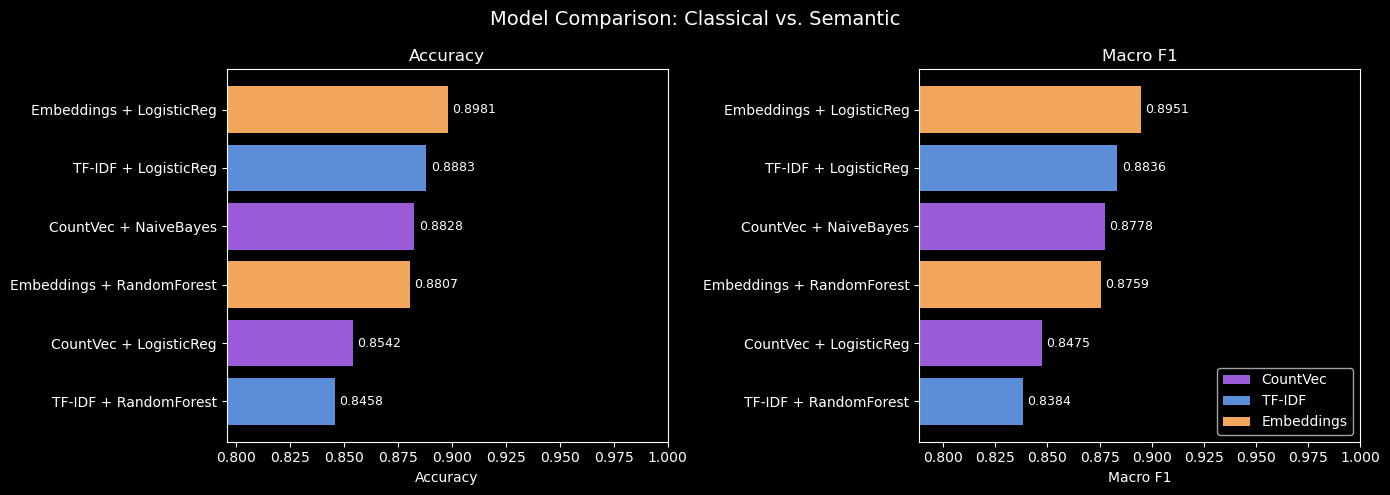

In [6]:
metrics = ['Accuracy', 'Macro F1']
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, metric in zip(axes, metrics):
    sorted_df = results_df.sort_values(metric, ascending=True)
    colors = []
    for name in sorted_df['Model']:
        if 'Embedding' in name:
            colors.append('#f1a65b')
        elif 'TF-IDF' in name:
            colors.append('#5b8dd9')
        else:
            colors.append('#9a5bd9')

    bars = ax.barh(sorted_df['Model'], sorted_df[metric], color=colors)
    ax.set_xlabel(metric)
    ax.set_title(metric)
    ax.set_xlim(sorted_df[metric].min() - 0.05, 1.0)
    for bar, val in zip(bars, sorted_df[metric]):
        ax.text(bar.get_width() + 0.002, bar.get_y() + bar.get_height()/2,
                f'{val:.4f}', va='center', fontsize=9)

# Legend patches
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='#9a5bd9', label='CountVec'),
    Patch(facecolor='#5b8dd9', label='TF-IDF'),
    Patch(facecolor='#f1a65b', label='Embeddings'),
]
axes[1].legend(handles=legend_elements, loc='lower right')
plt.suptitle('Model Comparison: Classical vs. Semantic', fontsize=14)
plt.tight_layout()
plt.show()

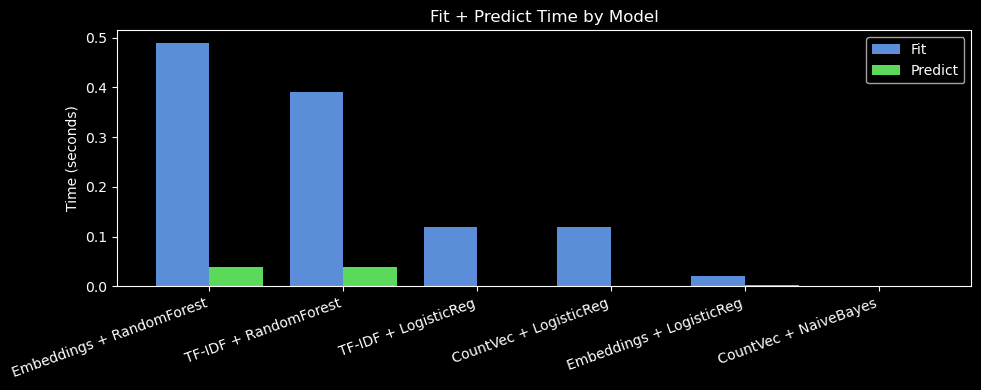


Note: embedding encoding time is NOT included here (it was done up front).
Add encode time to get the true total for embedding models.


In [7]:
# Speed comparison
speed_df = results_df[['Model', 'Fit (s)', 'Predict (s)']].copy()
speed_df['Total (s)'] = speed_df['Fit (s)'] + speed_df['Predict (s)']
speed_df = speed_df.sort_values('Total (s)', ascending=False)

fig, ax = plt.subplots(figsize=(10, 4))
x     = range(len(speed_df))
width = 0.4
ax.bar([i - width/2 for i in x], speed_df['Fit (s)'],    width, label='Fit',     color='#5b8dd9')
ax.bar([i + width/2 for i in x], speed_df['Predict (s)'],width, label='Predict', color='#5bd95b')
ax.set_xticks(list(x))
ax.set_xticklabels(speed_df['Model'], rotation=20, ha='right')
ax.set_ylabel('Time (seconds)')
ax.set_title('Fit + Predict Time by Model')
ax.legend()
plt.tight_layout()
plt.show()

print("\nNote: embedding encoding time is NOT included here (it was done up front).")
print("Add encode time to get the true total for embedding models.")

## 4. Error Analysis

Let's look at cases where the best classical model and the best embedding model **disagree** — one gets it right, the other doesn't. These cases reveal what each representation captures or misses.

In [8]:
# Identify best classical and best embedding model by Macro F1
classical_models = [r for r in rows if 'Embedding' not in r['Model']]
embedding_models = [r for r in rows if 'Embedding'     in r['Model']]

best_classical = max(classical_models, key=lambda r: r['Macro F1'])
best_embedding = max(embedding_models, key=lambda r: r['Macro F1'])

print(f"Best classical: {best_classical['Model']}  (F1={best_classical['Macro F1']})")
print(f"Best embedding: {best_embedding['Model']}  (F1={best_embedding['Macro F1']})")

preds_c = best_classical['_preds']
preds_e = best_embedding['_preds']
y_true  = test.target

# Cases: classical correct, embedding wrong
c_right_e_wrong = np.where((preds_c == y_true) & (preds_e != y_true))[0]
# Cases: embedding correct, classical wrong
e_right_c_wrong = np.where((preds_e == y_true) & (preds_c != y_true))[0]

print(f"\nClassical correct, Embedding wrong: {len(c_right_e_wrong)} cases")
print(f"Embedding correct, Classical wrong: {len(e_right_c_wrong)} cases")

Best classical: TF-IDF + LogisticReg  (F1=0.8836)
Best embedding: Embeddings + LogisticReg  (F1=0.8951)

Classical correct, Embedding wrong: 74 cases
Embedding correct, Classical wrong: 88 cases


In [9]:
# Show 2 examples where embedding wins
print("=== Cases where EMBEDDING wins but CLASSICAL fails ===\n")
for i in e_right_c_wrong[:2]:
    print(f"True:      {train.target_names[y_true[i]]}")
    print(f"Classical: {train.target_names[preds_c[i]]}  ✗")
    print(f"Embedding: {train.target_names[preds_e[i]]}  ✓")
    print(f"Text: {test.data[i][:300]}")
    print('-' * 60)

print("\n=== Cases where CLASSICAL wins but EMBEDDING fails ===\n")
for i in c_right_e_wrong[:2]:
    print(f"True:      {train.target_names[y_true[i]]}")
    print(f"Classical: {train.target_names[preds_c[i]]}  ✓")
    print(f"Embedding: {train.target_names[preds_e[i]]}  ✗")
    print(f"Text: {test.data[i][:300]}")
    print('-' * 60)

=== Cases where EMBEDDING wins but CLASSICAL fails ===

True:      talk.religion.misc
Classical: sci.space  ✗
Embedding: talk.religion.misc  ✓
Text: The universe, mirrored in a puddle.
Isn't it amazing how there *always* seems to be *another* bottle of bheer there?

Aleph *one* bottles of beer on the wall, Aleph *one* null bottles of beer!

	you, too, are a puddle.
	As above, so below.
------------------------------------------------------------
True:      comp.graphics
Classical: sci.space  ✗
Embedding: comp.graphics  ✓
Text: 

Is that the number of "left" legs, or both left and right?
------------------------------------------------------------

=== Cases where CLASSICAL wins but EMBEDDING fails ===

True:      sci.space
Classical: sci.space  ✓
Embedding: talk.religion.misc  ✗
Text: 

And from whence does this right stem, that it overrides the 'rights'
of the rest of us?


And if you want to view that television station, you have to watch the
commercials.  You can't turn them off and

## 5. Per-Category Breakdown

In [10]:
short_names = [c.split('.')[-1] for c in train.target_names]

print(f"{'='*55}")
print(f"Classification Report — {best_classical['Model']}")
print('='*55)
print(classification_report(y_true, preds_c, target_names=short_names))

print(f"{'='*55}")
print(f"Classification Report — {best_embedding['Model']}")
print('='*55)
print(classification_report(y_true, preds_e, target_names=short_names))

Classification Report — TF-IDF + LogisticReg
              precision    recall  f1-score   support

    graphics       0.90      0.90      0.90       389
      hockey       0.98      0.92      0.95       399
       space       0.79      0.93      0.85       394
        misc       0.93      0.75      0.83       251

    accuracy                           0.89      1433
   macro avg       0.90      0.88      0.88      1433
weighted avg       0.90      0.89      0.89      1433

Classification Report — Embeddings + LogisticReg
              precision    recall  f1-score   support

    graphics       0.94      0.92      0.93       389
      hockey       0.90      0.96      0.93       399
       space       0.85      0.86      0.85       394
        misc       0.90      0.84      0.87       251

    accuracy                           0.90      1433
   macro avg       0.90      0.89      0.90      1433
weighted avg       0.90      0.90      0.90      1433



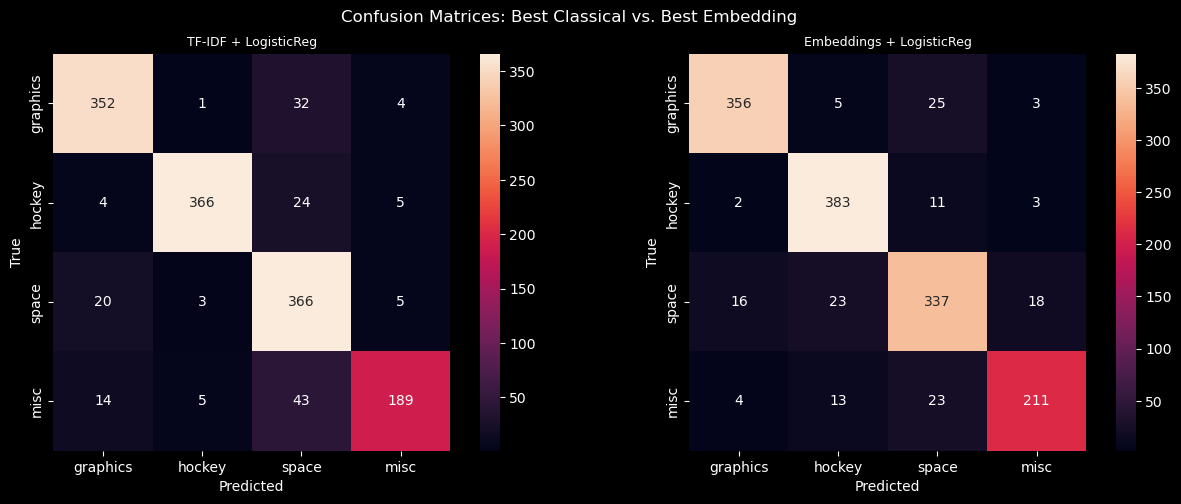

In [12]:
# Confusion matrices side by side
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for ax, preds, name in [
    (axes[0], preds_c, best_classical['Model']),
    (axes[1], preds_e, best_embedding['Model']),
]:
    cm = confusion_matrix(y_true, preds)
    sns.heatmap(cm, annot=True, fmt='d', square=True,
                xticklabels=short_names, yticklabels=short_names, ax=ax)
    ax.set_xlabel('Predicted')
    ax.set_ylabel('True')
    ax.set_title(name, fontsize=9)

plt.suptitle('Confusion Matrices: Best Classical vs. Best Embedding', fontsize=12)
plt.tight_layout()
plt.show()

## Conclusion — When to Use What

| Factor | Classical (CountVec/TF-IDF) | Semantic (Embeddings) |
|---|---|---|
| **Accuracy** | Good | Often better |
| **Speed** | Fast | Slower (inference) |
| **Interpretability** | High — features are words | Low — features are latent dims |
| **Data size** | Works well with small corpora | Shines on small datasets (pre-trained) |
| **Domain transfer** | Weak — vocab must match | Strong — pre-trained on broad text |
| **Memory** | Sparse (efficient) | Dense (larger) |

### Practical rules of thumb

- **Start with TF-IDF + Logistic Regression.** It's fast, interpretable, and surprisingly strong.
- **Use SHAP or LR coefficients** to understand what the classical model learned.
- **Upgrade to embeddings** when you need better generalization, have short texts, or the vocabulary varies a lot between train and test.
- **Don't use Random Forest on text** unless you have a specific reason — it's slow and rarely beats LR on sparse features.

---
*Series complete: Tokenization → Vectorization → Classification → Embeddings → Comparison*